# NYC Yellow Taxi Trips — ML Prediction Analysis
**Branch: Data Analysis | Notebook 06**

---

## Objective

This notebook analyses the BigQuery ML model trained to predict the total amount of a NYC Yellow Taxi trip. It covers model evaluation, feature importance interpretation, and prediction examples.

**This notebook answers the following questions:**
- How accurately can we predict the total fare of a trip?
- Which variables influence the predicted amount the most?
- What do the model coefficients tell us about the pricing structure?
- Where does the model struggle and why?

---

**Model:** Linear Regression (BigQuery ML)  
**Target:** `total_amount` — total amount charged to the passenger  
**Training data:** 161,845 trips sampled from `ml_dataset.trips_ml_sample`  
**Sampling method:** Deterministic sampling via FARM_FINGERPRINT (2% of dataset)

---

In [1]:
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from config.bq_config import run_query, PROJECT_ID

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')

print("Setup complete.")
print(f"Project: {PROJECT_ID}")

Setup complete.
Project: ny-yellow-taxi-trips


## 2. Model Evaluation Metrics

In [2]:
# Fetch model evaluation metrics
df_eval = run_query("""
    SELECT *
    FROM ML.EVALUATE(
        MODEL `ny-yellow-taxi-trips.ml_dataset.yellow_trips_model`,
        (SELECT * FROM `ny-yellow-taxi-trips.ml_dataset.trips_ml_sample`)
    )
""")

mae  = df_eval['mean_absolute_error'].iloc[0]
mse  = df_eval['mean_squared_error'].iloc[0]
rmse = np.sqrt(mse)
r2   = df_eval['r2_score'].iloc[0]
ev   = df_eval['explained_variance'].iloc[0]

print("=" * 50)
print("MODEL EVALUATION — yellow_trips_model")
print("=" * 50)
print(f"  Model type         : Linear Regression (BigQuery ML)")
print(f"  Training rows      : 161,845")
print(f"  Features           : 11")
print(f"  MAE                : ${mae:.4f}")
print(f"  RMSE               : ${rmse:.4f}")
print(f"  R² Score           : {r2:.4f}")
print(f"  Explained Variance : {ev:.4f}")
print("=" * 50)

MODEL EVALUATION — yellow_trips_model
  Model type         : Linear Regression (BigQuery ML)
  Training rows      : 161,845
  Features           : 11
  MAE                : $2.8613
  RMSE               : $4.1374
  R² Score           : 0.9649
  Explained Variance : 0.9649


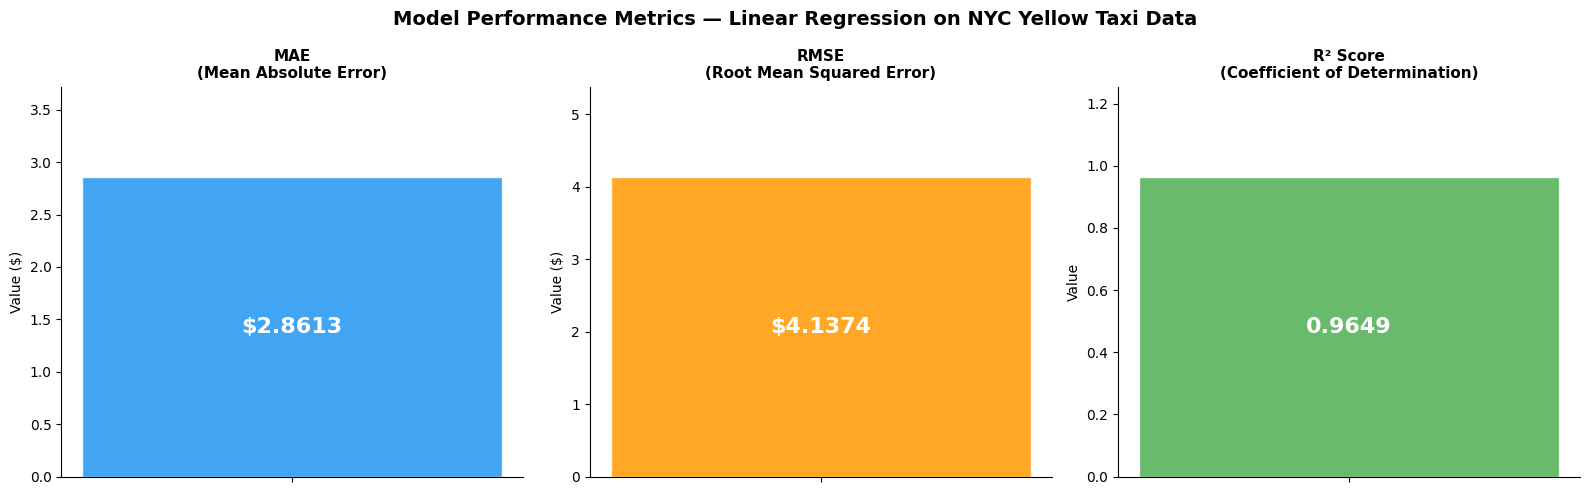

Chart saved to exports/06_model_metrics.png


In [3]:
# Visualize metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Model Performance Metrics — Linear Regression on NYC Yellow Taxi Data',
             fontsize=14, fontweight='bold')

metrics_data = [
    ('MAE\n(Mean Absolute Error)', mae, '$', '#2196F3'),
    ('RMSE\n(Root Mean Squared Error)', rmse, '$', '#FF9800'),
    ('R² Score\n(Coefficient of Determination)', r2, '', '#4CAF50')
]

for ax, (label, value, unit, color) in zip(axes, metrics_data):
    ax.bar([''], [value], color=color, alpha=0.85, width=0.4, edgecolor='white')
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.set_ylabel(f'Value ({unit})' if unit else 'Value')
    ax.text(0, value / 2, f'{unit}{value:.4f}',
            ha='center', va='center', fontsize=16, fontweight='bold', color='white')
    ax.set_ylim(0, max(value * 1.3, 1.0))

plt.tight_layout()
plt.savefig('../exports/06_model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to exports/06_model_metrics.png")

## 3. Feature Importance — Model Coefficients

In [4]:
# Fetch model weights
df_weights = run_query("""
    SELECT
        processed_input AS feature,
        ROUND(ABS(weight), 4) AS importance,
        ROUND(weight, 4) AS coefficient,
        CASE WHEN weight > 0 THEN 'Positive' ELSE 'Negative' END AS direction
    FROM ML.WEIGHTS(MODEL `ny-yellow-taxi-trips.ml_dataset.yellow_trips_model`)
    WHERE processed_input != '__INTERCEPT__'
    ORDER BY importance DESC
""")

print("Feature coefficients (sorted by absolute importance):")
print(df_weights.to_string(index=False))

Feature coefficients (sorted by absolute importance):
             feature  importance  coefficient direction
        payment_type      7.4124      -7.4124  Negative
             mta_tax      3.5112      -3.5112  Negative
         airport_fee      2.4478       2.4478  Positive
congestion_surcharge      2.1652       2.1652  Positive
        tolls_amount      1.2056       1.2056  Positive
         fare_amount      1.0835       1.0835  Positive
               extra      0.8550       0.8550  Positive
     passenger_count      0.0678       0.0678  Positive
        DOLocationID      0.0016      -0.0016  Negative
        PULocationID      0.0011       0.0011  Positive
       trip_distance      0.0005      -0.0005  Negative


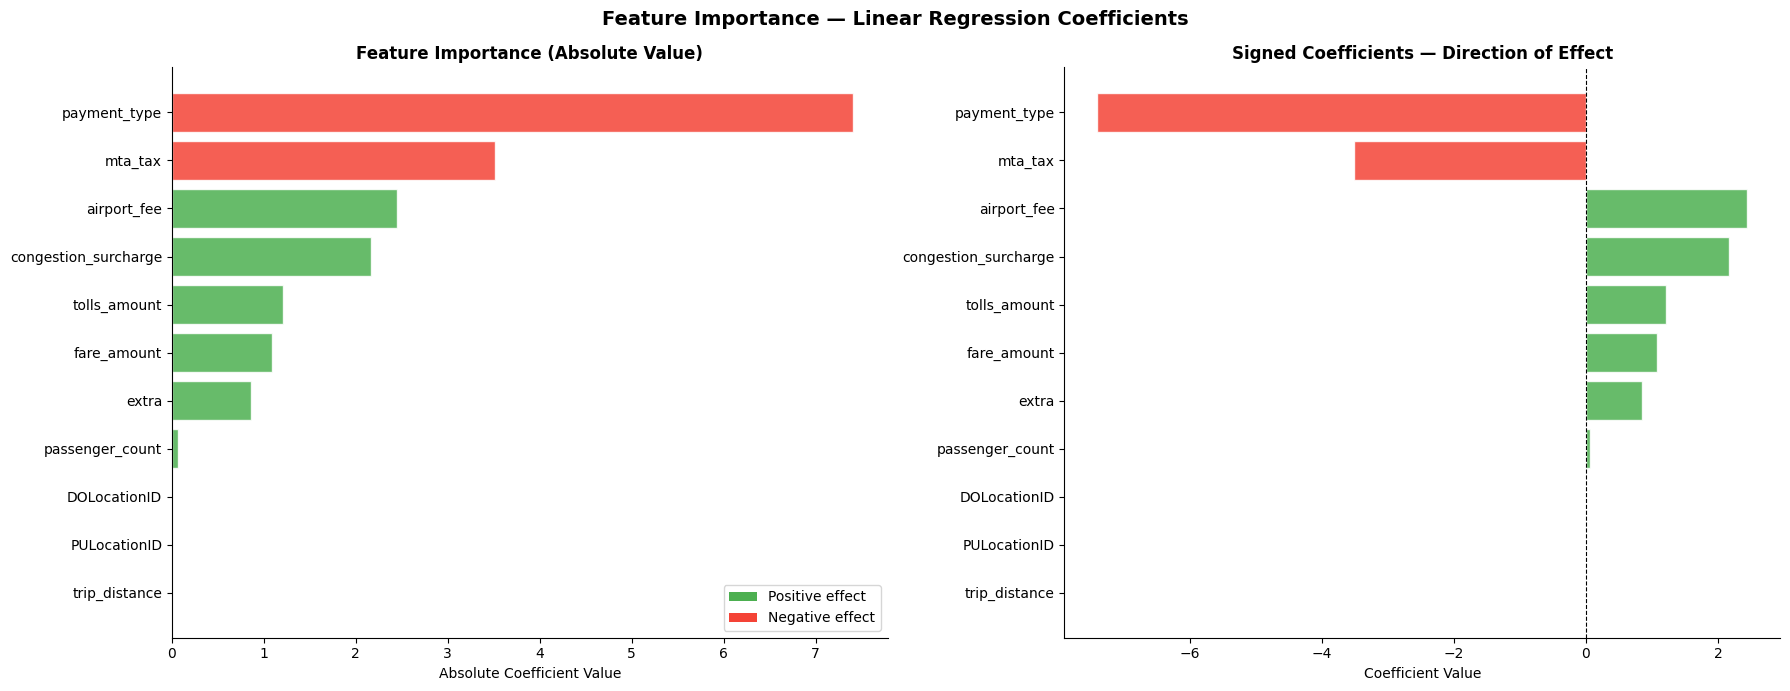

Chart saved to exports/06_feature_importance.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Feature Importance — Linear Regression Coefficients',
             fontsize=14, fontweight='bold')

colors = ['#4CAF50' if d == 'Positive' else '#F44336'
          for d in df_weights['direction']]

axes[0].barh(df_weights['feature'], df_weights['importance'],
             color=colors, alpha=0.85, edgecolor='white')
axes[0].set_title('Feature Importance (Absolute Value)', fontweight='bold')
axes[0].set_xlabel('Absolute Coefficient Value')
axes[0].invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#4CAF50', label='Positive effect'),
    Patch(facecolor='#F44336', label='Negative effect')
]
axes[0].legend(handles=legend_elements, loc='lower right')

colors_signed = ['#4CAF50' if c > 0 else '#F44336'
                 for c in df_weights['coefficient']]
axes[1].barh(df_weights['feature'], df_weights['coefficient'],
             color=colors_signed, alpha=0.85, edgecolor='white')
axes[1].set_title('Signed Coefficients — Direction of Effect', fontweight='bold')
axes[1].set_xlabel('Coefficient Value')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../exports/06_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to exports/06_feature_importance.png")

## 4. Prediction Examples

In [6]:
# Generate predictions on a sample
df_predictions = run_query("""
    SELECT
        predicted_total_amount AS predicted_total,
        total_amount AS actual_total,
        fare_amount,
        trip_distance,
        passenger_count,
        payment_type,
        ROUND(ABS(predicted_total_amount - total_amount), 2) AS absolute_error
    FROM ML.PREDICT(
        MODEL `ny-yellow-taxi-trips.ml_dataset.yellow_trips_model`,
        (SELECT * FROM `ny-yellow-taxi-trips.ml_dataset.trips_ml_sample`
         WHERE total_amount BETWEEN 2.5 AND 100
         LIMIT 5000)
    )
""")

print(f"Prediction sample size: {len(df_predictions):,} trips")
print(f"\nError distribution:")
print(df_predictions['absolute_error'].describe().round(2).to_string())

Prediction sample size: 5,000 trips

Error distribution:
count    5000.00
mean        3.09
std         2.41
min         0.00
25%         1.31
50%         2.21
75%         4.93
max        20.14


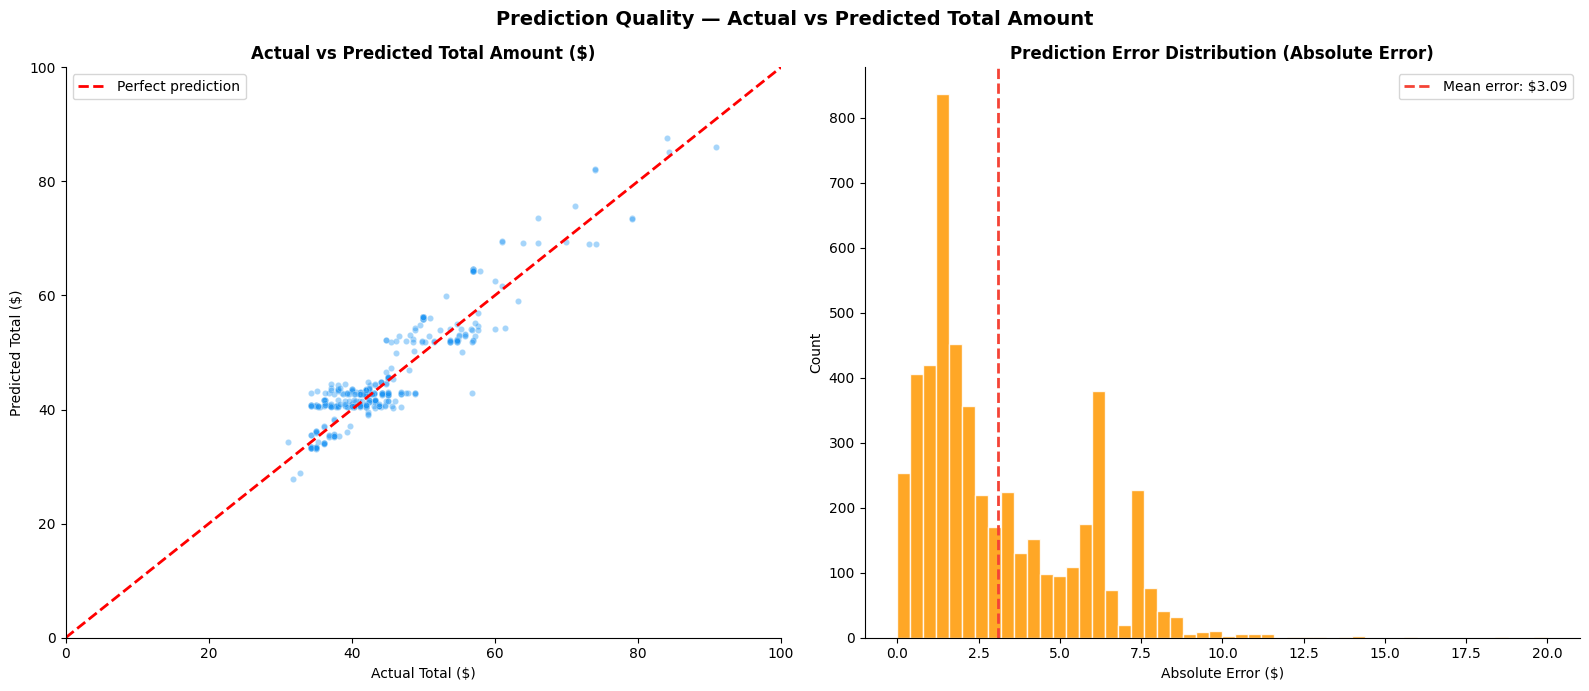

Chart saved to exports/06_prediction_quality.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Prediction Quality — Actual vs Predicted Total Amount',
             fontsize=14, fontweight='bold')

# Actual vs Predicted scatter
sample = df_predictions.sample(min(500, len(df_predictions)))
axes[0].scatter(sample['actual_total'], sample['predicted_total'],
                alpha=0.4, color='#2196F3', s=20, edgecolors='white', linewidth=0.3)
max_val = max(sample['actual_total'].max(), sample['predicted_total'].max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_title('Actual vs Predicted Total Amount ($)', fontweight='bold')
axes[0].set_xlabel('Actual Total ($)')
axes[0].set_ylabel('Predicted Total ($)')
axes[0].legend()
axes[0].set_xlim(0, 100)
axes[0].set_ylim(0, 100)

# Error distribution
mean_error = df_predictions['absolute_error'].mean()
axes[1].hist(df_predictions['absolute_error'].clip(0, 20), bins=50,
             color='#FF9800', alpha=0.85, edgecolor='white')
axes[1].axvline(mean_error, color='#F44336', linestyle='--', linewidth=2,
                label=f'Mean error: ${mean_error:.2f}')
axes[1].set_title('Prediction Error Distribution (Absolute Error)', fontweight='bold')
axes[1].set_xlabel('Absolute Error ($)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../exports/06_prediction_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to exports/06_prediction_quality.png")

## 5. Methodological Notes & Limitations

### Model Choice — Why Linear Regression?

Linear Regression was selected over more complex models (Gradient Boosting, Neural Networks) for the following reasons:

- **Interpretability**: Coefficients are directly readable and explainable to non-technical stakeholders
- **Efficiency**: Trains in minutes on BigQuery ML vs hours for tree-based models at this scale
- **Data structure**: `total_amount` is an arithmetic sum of its components — a linear relationship is the correct model for this structure
- **Performance**: R² of 0.965 confirms the linear assumption is valid for this dataset

### Key Methodological Limitations

**1. Evaluation on training data**  
The evaluation metrics (R², MAE, RMSE) are computed on the same sample used for training — not on a separate holdout set. This means the reported metrics are optimistic. A rigorous evaluation would require splitting the data into train/test sets before model creation. This is a valid next step for improving model rigor.

**2. payment_type is the strongest predictor — for the wrong reason**  
The model assigns the highest importance to `payment_type`. This is not because the payment method changes the price — it is because cash tips are not recorded in the TLC dataset. Credit card trips include tip amounts in `total_amount`; cash trips do not. The model has learned this data recording artifact, not a true causal relationship.

**3. This model explains pricing structure — it does not predict future trips**  
The features used (fare_amount, tip_amount, tolls_amount, congestion_surcharge, airport_fee) are all known only after a trip ends. A truly predictive model — useful for estimating a fare before departure — would use only pre-trip variables: trip_distance, PULocationID, DOLocationID, passenger_count, hour of day, day of week. The current model illustrates the NYC TLC pricing structure rather than enabling real-time fare prediction.

**4. trip_distance coefficient is near zero**  
This does not mean distance does not affect price. Distance determines `fare_amount`, which is already in the model. The effect of distance is fully captured through `fare_amount` — the model correctly identifies this redundancy.

**5. Training on a sample**  
The model was trained on 161,845 trips (0.8% of the full dataset) using deterministic FARM_FINGERPRINT sampling. This ensures representativeness across zones, payment types, and trip profiles — but predictions on very rare trip types may be less accurate.

---